In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load MNIST
mnist = fetch_openml('mnist_784', version=1)

# Convert to pure numpy arrays
X = mnist.data.to_numpy().astype(np.float32)
y = mnist.target.to_numpy().astype(int)

# Normalize
X = X / 255.0

# Check data balance
classes, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(classes, counts):
    print(f"Class {cls}: {cnt}")



# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Train:", X_train.shape, "Test:", X_test.shape)

Class 0: 6903
Class 1: 7877
Class 2: 6990
Class 3: 7141
Class 4: 6824
Class 5: 6313
Class 6: 6876
Class 7: 7293
Class 8: 6825
Class 9: 6958
Train: (56000, 784) Test: (14000, 784)


In [2]:
from collections import Counter
from sklearn.metrics import accuracy_score, recall_score, f1_score

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []

        for x in X:
            distances = np.linalg.norm(self.X_train - x, axis=1) #vector normalization
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]

            most_common = Counter(k_labels).most_common(1)
            predictions.append(most_common[0][0])

        return np.array(predictions)

# Train
knn = KNN(k=3)
knn.fit(X_train[:2000], y_train[:2000])

# Predict
y_pred = knn.predict(X_test[:500])

# Metrics
print("Accuracy:", accuracy_score(y_test[:500], y_pred))
print("Recall:", recall_score(y_test[:500], y_pred, average='macro'))
print("F1:", f1_score(y_test[:500], y_pred, average='macro'))

Accuracy: 0.92
Recall: 0.916547550436827
F1: 0.9177390590448218


<Figure size 800x800 with 0 Axes>

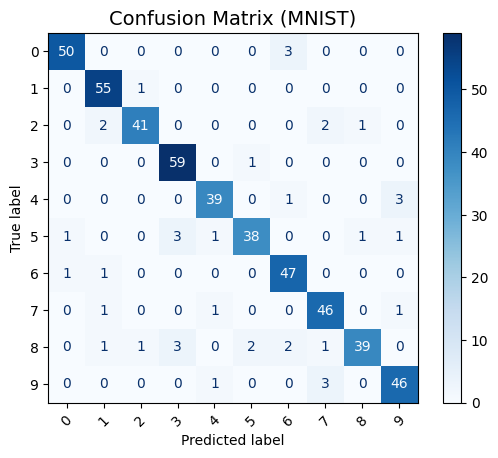

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = [str(i) for i in range(10)]

cm = confusion_matrix(y_test[:500], y_pred)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix (MNIST)", fontsize=14)
plt.xticks(rotation=45)
plt.grid(False)

plt.show()

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.9712857142857143
Recall: 0.9708657044620269
F1: 0.9711991586660975


In [5]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

class GaussianNB_Custom:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0) + 1e-6
            self.priors[c] = X_c.shape[0] / X.shape[0]

    def gaussian_prob(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(- (x - mean)**2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = []

            for c in self.classes:
                prior = np.log(self.priors[c])
                conditional = np.sum(np.log(self.gaussian_prob(c, x)))
                posterior = prior + conditional
                posteriors.append(posterior)

            predictions.append(self.classes[np.argmax(posteriors)])

        return np.array(predictions)

# Train
nb = GaussianNB_Custom()
nb.fit(X_train, y_train)

# Predict
y_pred = nb.predict(X_test[:1000])

# Metrics
print("Accuracy:", accuracy_score(y_test[:1000], y_pred))
print("Recall:", recall_score(y_test[:1000], y_pred, average='macro'))
print("F1:", f1_score(y_test[:1000], y_pred, average='macro'))

/tmp/ipykernel_16454/970102483.py:31: RuntimeWarning: divide by zero encountered in log
  conditional = np.sum(np.log(self.gaussian_prob(c, x)))


Accuracy: 0.63
Recall: 0.6197684860558167
F1: 0.5983455882430425


In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, f1_score

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.5515714285714286
Recall: 0.5414664953557429
F1: 0.49638803424044936
